# Superstore - Exploratory Data Analysis
This notebook analyses a US Superstore retail dataset covering sales, profit, and customer segments.

**Name:** Tshegofatso Chikwane

## Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Inspect the Data
We load the CSV file and check its shape, columns and first few rows.

In [13]:
# LOAD AND INSPECT THE DATA

In [14]:
df = pd.read_csv('superstore.csv', encoding='latin1')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: 9994 rows, 21 columns

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [15]:
print("Data types:")
df.dtypes

Data types:


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [16]:
df.head(5)  # shows the top 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
df.tail(5)  # shows the bottom 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [18]:
df.info()   # shows variables and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 2. Check for Missing Values
Missing values are empty cells. We need to find them before cleaning.

In [19]:
missing = df.isnull().sum()  # checking for missing values

print("Missing Values per column:")
missing[missing > 0]

Missing Values per column:


Series([], dtype: int64)

## 3. Check for Duplicates
Duplicate rows are exact copies of each other. They skew our results so we remove them.

In [20]:
# checking for duplicates
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [21]:
# basic stats
basic_stats = df.describe()

print("Basic Stats:")
basic_stats

Basic Stats:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 4. Data Cleaning
We fix date columns, extract useful time features, and add a shipping days column.

In [22]:
# remove duplicates
df = df.drop_duplicates()

In [23]:
# fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

In [24]:
# extract useful time columns
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day']   = df['Order Date'].dt.day_name()

In [25]:
# add shipping days column
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [26]:
# check rows remaining after data cleaning
print("\nAFTER DATA CLEANING")
print("Rows remaining:", len(df))
print("New columns added: Order Year, Order Month, Order Day, Shipping Days")


AFTER DATA CLEANING
Rows remaining: 9994
New columns added: Order Year, Order Month, Order Day, Shipping Days


In [27]:
# exploring clean data

# key metrics
print("\n--- KEY METRICS ---")
print(f"Total Sales:     ${df['Sales'].sum():,.2f}")
print(f"Total Profit:    ${df['Profit'].sum():,.2f}")
print(f"Total Orders:    {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Total Products:  {df['Product Name'].nunique():,}")
print(f"Profit Margin:   {(df['Profit'].sum() / df['Sales'].sum() * 100):.2f}%")


--- KEY METRICS ---
Total Sales:     $2,297,200.86
Total Profit:    $286,397.02
Total Orders:    5,009
Total Customers: 793
Total Products:  1,850
Profit Margin:   12.47%


In [28]:
# sales by category
print("\n--- SALES BY CATEGORY ---")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).round(2))


--- SALES BY CATEGORY ---
Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64


In [29]:
# sales by region
print("\n--- SALES BY REGION ---")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2))


--- SALES BY REGION ---
Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64


In [30]:
# monthly sales
print("\n--- MONTHLY SALES ---")
print(df.groupby('Order Month')['Sales'].sum().round(2))


--- MONTHLY SALES ---
Order Month
1      94924.84
2      59751.25
3     205005.49
4     137762.13
5     155028.81
6     152718.68
7     147238.10
8     159044.06
9     307649.95
10    200322.98
11    352461.07
12    325293.50
Name: Sales, dtype: float64


## 5. Visualizations
Now that the data is clean, we explore it using different types of charts.

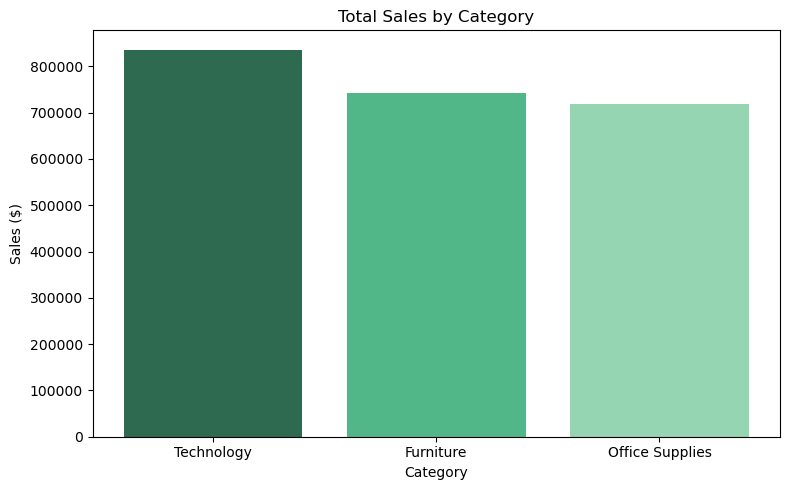

In [31]:
# Chart 1: Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values, color=['#2d6a4f','#52b788','#95d5b2'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

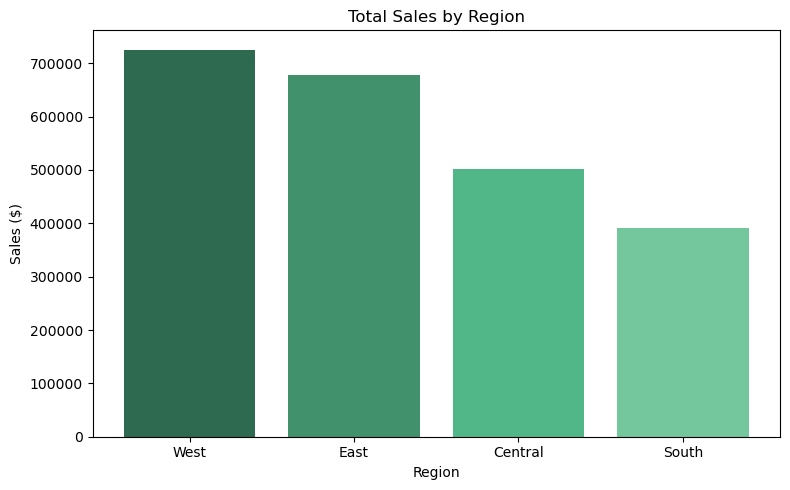

In [32]:
# Chart 2: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values, color=['#2d6a4f','#40916c','#52b788','#74c69d'])
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

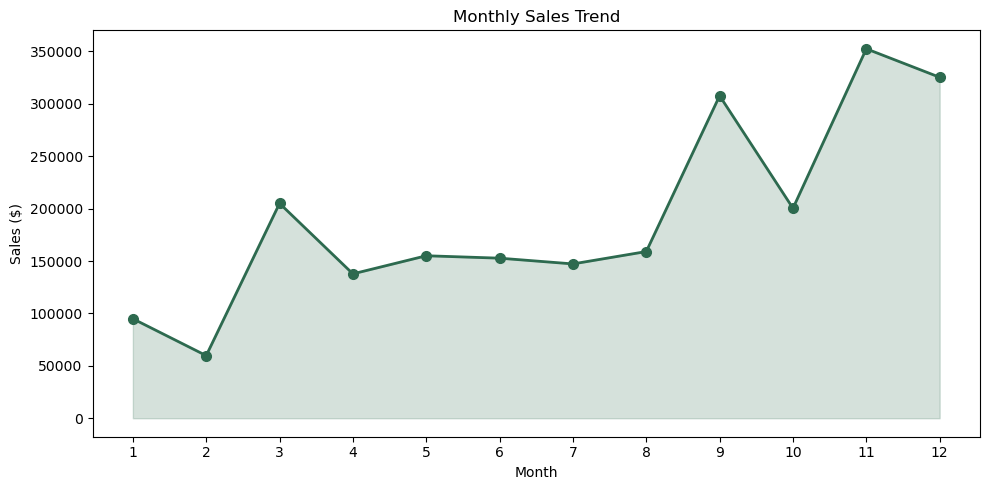

In [33]:
# Chart 3: Monthly Sales Trend - LINE CHART
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, color='#2d6a4f', marker='o', linewidth=2, markersize=7)
plt.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.2, color='#2d6a4f')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

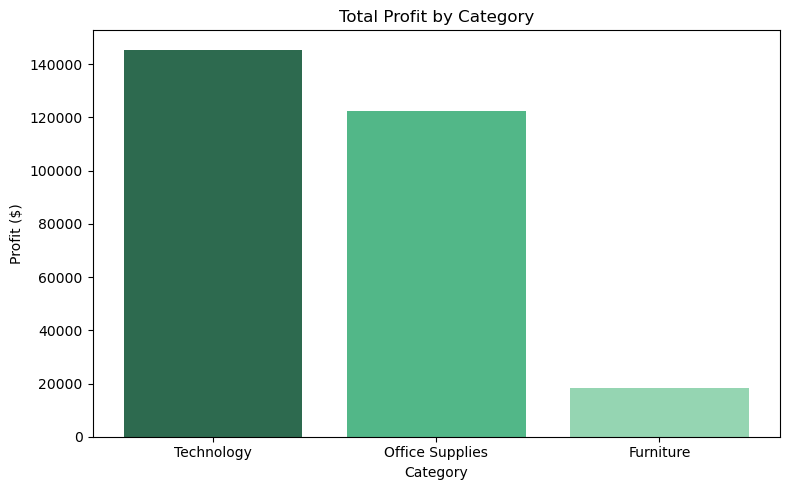

In [34]:
# Chart 4: Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_profit.index, category_profit.values, color=['#2d6a4f','#52b788','#95d5b2'])
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

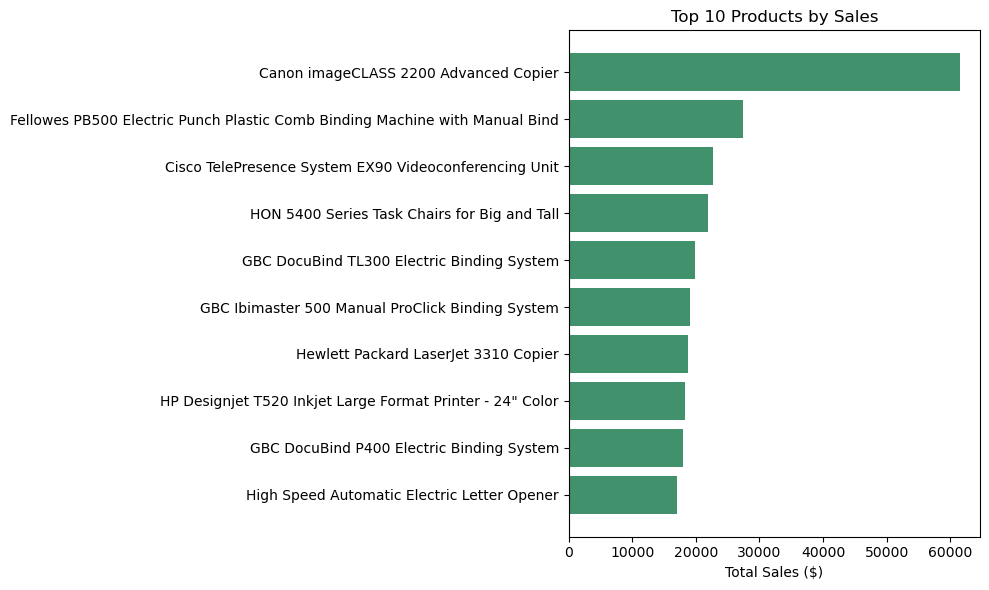

In [35]:
# Chart 5: Top 10 Products by Sales - HORIZONTAL BAR CHART
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_products.index[::-1], top_products.values[::-1], color='#40916c')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

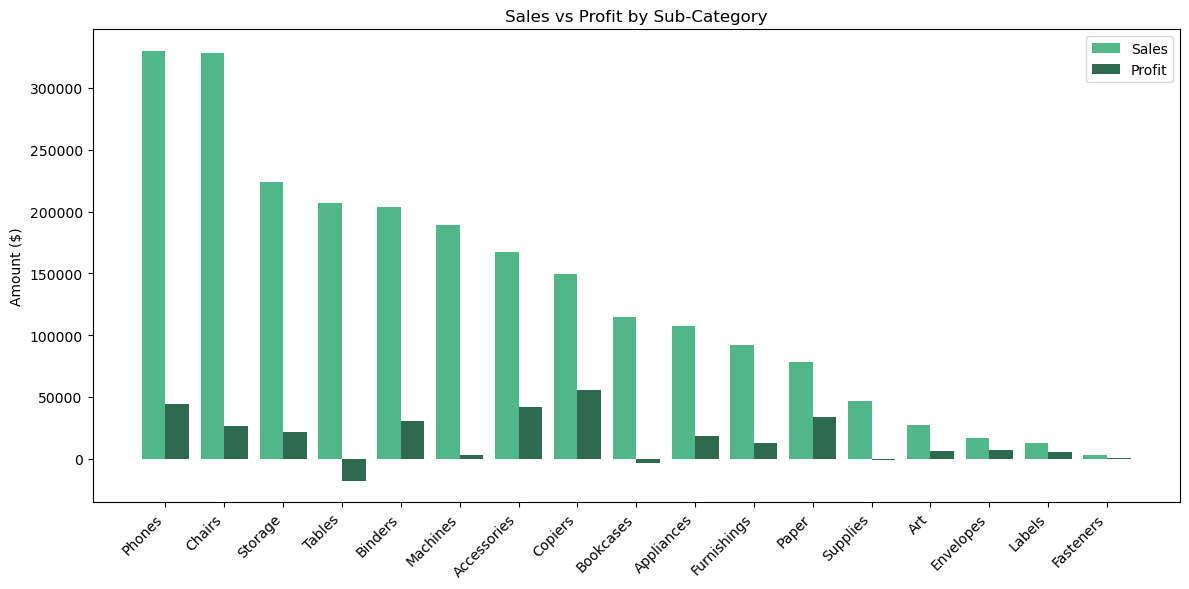

In [36]:
# Chart 6: Sales vs Profit by Sub-Category
sub_cat = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(sub_cat))
ax.bar([i - 0.2 for i in x], sub_cat['Sales'],  width=0.4, label='Sales',  color='#52b788')
ax.bar([i + 0.2 for i in x], sub_cat['Profit'], width=0.4, label='Profit', color='#2d6a4f')
ax.set_xticks(x)
ax.set_xticklabels(sub_cat.index, rotation=45, ha='right')
ax.set_title('Sales vs Profit by Sub-Category')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

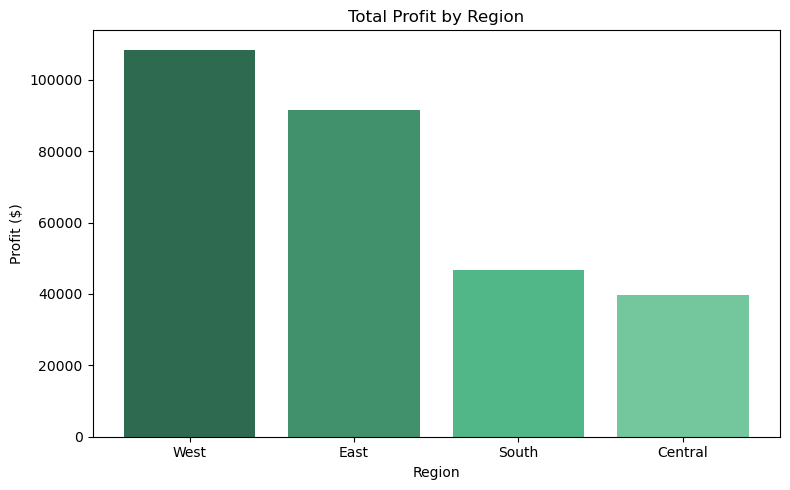

In [37]:
# Chart 7: Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_profit.index, region_profit.values, color=['#2d6a4f','#40916c','#52b788','#74c69d'])
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

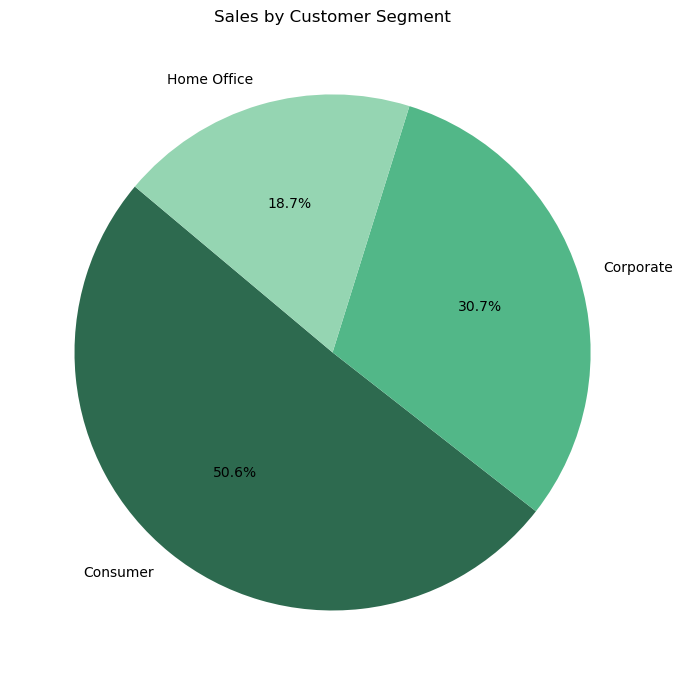

In [38]:
# Chart 8: Sales by Customer Segment - PIE CHART
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(segment_sales.values, labels=segment_sales.index,
        autopct='%1.1f%%',
        colors=['#2d6a4f','#52b788','#95d5b2'],
        startangle=140)
plt.title('Sales by Customer Segment')
plt.tight_layout()
plt.show()

## 6. Save the Clean Data
We save the cleaned dataset as a new CSV file for future use.

In [39]:
# save clean data
df.to_csv('superstore_clean.csv', index=False)
print("Clean data saved as superstore_clean.csv")

Clean data saved as superstore_clean.csv
